# 02 — Furnishing Condition Model Training

Fine-tunes EfficientNet-B0 on the 1,000-image indoor dataset prepared in `01_photo_data_prep.ipynb`.

**Architecture:**
- EfficientNet-B0 (ImageNet pretrained) → replace classifier with `Dropout(0.3) → Linear(1280,1)` regression head
- Output clamped to [0, 10]

**Two-stage training:**
1. Freeze backbone → train head only (5 epochs, fast)
2. Unfreeze last 3 blocks → end-to-end fine-tune at 10× lower LR

**Outputs (to `artifacts/`):**
- `condition_model_YYYYMMDD.pth` — model weights
- `condition_model_meta_YYYYMMDD.json` — training metadata

> **GPU recommended.** Runs on CPU but will be slow. Use Google Colab T4 if no local GPU.

In [ ]:
# stdlib
import json
import time
from datetime import date
from pathlib import Path

# third-party
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torchvision.models as tv_models
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from PIL import Image

# ── Paths ──────────────────────────────────────────────────────────────────────
HERE = Path.cwd()
REPO_ROOT   = HERE if (HERE / 'hf_data').exists() else HERE.parent
LAYER_ROOT  = REPO_ROOT / '05_photo_layer'
DATA_DIR    = LAYER_ROOT / 'data'
ARTIFACT_DIR = LAYER_ROOT / 'artifacts'
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

TODAY = date.today().strftime('%Y%m%d')

# ── Device: prefer CUDA, then MPS (Apple Silicon), then CPU ───────────────────
if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
elif torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
else:
    DEVICE = torch.device('cpu')

print(f'Device : {DEVICE}')
print(f'Today  : {TODAY}')

In [2]:
# ── Hyper-parameters ───────────────────────────────────────────────────────────
STAGE1_EPOCHS = 5       # head-only training
STAGE2_EPOCHS = 10      # end-to-end fine-tune
BATCH_SIZE    = 32
LR_STAGE1     = 1e-3
LR_STAGE2     = 1e-4    # 10× lower
RANDOM_SEED   = 42

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

## 1. Dataset

In [ ]:
class InteriorPhotoDataset(Dataset):
    """Loads interior photos and their 0-10 condition scores."""

    def __init__(self, csv_path: Path, transform=None):
        self.df = pd.read_csv(csv_path)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['image_path']).convert('RGB')
        if self.transform:
            img = self.transform(img)
        score = torch.tensor(float(row['ava_score_0_10']), dtype=torch.float32)
        return img, score


train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

val_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

train_dataset = InteriorPhotoDataset(DATA_DIR / 'photo_labels_train.csv', transform=train_transforms)
val_dataset   = InteriorPhotoDataset(DATA_DIR / 'photo_labels_val.csv',   transform=val_transforms)

# pin_memory only benefits CUDA; num_workers=0 avoids macOS multiprocessing issues
_pin = DEVICE.type == 'cuda'
_workers = 0 if DEVICE.type == 'mps' else 2

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=_workers, pin_memory=_pin)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=_workers, pin_memory=_pin)

print(f'Train samples : {len(train_dataset)}')
print(f'Val   samples : {len(val_dataset)}')
print(f'pin_memory    : {_pin}  |  num_workers: {_workers}')

## 2. Model

EfficientNet-B0 with a regression head replacing the default 1000-class classifier.

In [4]:
def build_model() -> nn.Module:
    model = tv_models.efficientnet_b0(weights=tv_models.EfficientNet_B0_Weights.IMAGENET1K_V1)
    in_features = model.classifier[1].in_features  # 1280
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.3, inplace=True),
        nn.Linear(in_features, 1),
    )
    return model


model = build_model().to(DEVICE)
print(f'EfficientNet-B0 loaded. Classifier: {model.classifier}')

EfficientNet-B0 loaded. Classifier: Sequential(
  (0): Dropout(p=0.3, inplace=True)
  (1): Linear(in_features=1280, out_features=1, bias=True)
)


## 3. Training helpers

In [5]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0.0
    for imgs, scores in loader:
        imgs, scores = imgs.to(DEVICE), scores.to(DEVICE)
        optimizer.zero_grad()
        preds = model(imgs).squeeze(1).clamp(0.0, 10.0)
        loss = criterion(preds, scores)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(imgs)
    return total_loss / len(loader.dataset)


def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    all_preds, all_targets = [], []
    with torch.no_grad():
        for imgs, scores in loader:
            imgs, scores = imgs.to(DEVICE), scores.to(DEVICE)
            preds = model(imgs).squeeze(1).clamp(0.0, 10.0)
            total_loss += criterion(preds, scores).item() * len(imgs)
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(scores.cpu().numpy())
    mae = np.mean(np.abs(np.array(all_preds) - np.array(all_targets)))
    return total_loss / len(loader.dataset), float(mae)


def r2_score(preds, targets):
    ss_res = np.sum((preds - targets) ** 2)
    ss_tot = np.sum((targets - targets.mean()) ** 2)
    return 1 - ss_res / ss_tot if ss_tot > 0 else float('nan')

## 4. Stage 1 — Train head only (backbone frozen)

In [6]:
# Freeze all backbone parameters
for name, param in model.named_parameters():
    if 'classifier' not in name:
        param.requires_grad = False

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Stage 1 — trainable parameters: {trainable:,}')

criterion  = nn.HuberLoss(delta=1.0)
optimizer1 = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR_STAGE1,
)
scheduler1 = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer1, mode='min', patience=2, factor=0.5
)

print('\nEpoch  |  Train Loss  |  Val Loss  |  Val MAE')
print('-' * 50)
stage1_history = []
t0 = time.time()
for epoch in range(1, STAGE1_EPOCHS + 1):
    train_loss           = train_epoch(model, train_loader, optimizer1, criterion)
    val_loss, val_mae    = eval_epoch(model, val_loader, criterion)
    scheduler1.step(val_loss)
    stage1_history.append({'epoch': epoch, 'train_loss': train_loss,
                           'val_loss': val_loss, 'val_mae': val_mae})
    print(f'  {epoch:3d}  |   {train_loss:.4f}    |   {val_loss:.4f}   |   {val_mae:.4f}')

print(f'\nStage 1 complete in {time.time() - t0:.1f}s')

Stage 1 — trainable parameters: 1,281

Epoch  |  Train Loss  |  Val Loss  |  Val MAE
--------------------------------------------------


    1  |   1.7473    |   0.7834   |   1.2011


    2  |   0.7954    |   0.9169   |   1.3451


    3  |   0.7402    |   0.8513   |   1.2815


    4  |   0.7075    |   0.8409   |   1.2624


    5  |   0.6513    |   0.7957   |   1.2124

Stage 1 complete in 11.2s


## 5. Stage 2 — Fine-tune last 3 blocks end-to-end

In [7]:
# Unfreeze last 3 MBConv blocks of EfficientNet-B0 (features[5], [6], [7])
unfreeze_blocks = {'features.5', 'features.6', 'features.7', 'classifier'}
for name, param in model.named_parameters():
    if any(name.startswith(blk) for blk in unfreeze_blocks):
        param.requires_grad = True

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Stage 2 — trainable parameters: {trainable:,}')

optimizer2 = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR_STAGE2,
)
scheduler2 = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer2, mode='min', patience=3, factor=0.5
)

best_val_mae = 1e9
best_state   = None

print('\nEpoch  |  Train Loss  |  Val Loss  |  Val MAE  |  Best')
print('-' * 60)
stage2_history = []
t0 = time.time()
for epoch in range(1, STAGE2_EPOCHS + 1):
    train_loss           = train_epoch(model, train_loader, optimizer2, criterion)
    val_loss, val_mae    = eval_epoch(model, val_loader, criterion)
    scheduler2.step(val_loss)

    is_best = val_mae < best_val_mae
    if is_best:
        best_val_mae = val_mae
        best_state   = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    stage2_history.append({'epoch': epoch, 'train_loss': train_loss,
                           'val_loss': val_loss, 'val_mae': val_mae,
                           'best': is_best})
    flag = '  ← best' if is_best else ''
    print(f'  {epoch:3d}  |   {train_loss:.4f}    |   {val_loss:.4f}   |   {val_mae:.4f}  {flag}')

print(f'\nStage 2 complete in {time.time() - t0:.1f}s')
print(f'Best val MAE: {best_val_mae:.4f}')

Stage 2 — trainable parameters: 3,288,009

Epoch  |  Train Loss  |  Val Loss  |  Val MAE  |  Best
------------------------------------------------------------


    1  |   0.5059    |   0.4413   |   0.8202    ← best


    2  |   0.3209    |   0.3332   |   0.6974    ← best


    3  |   0.2395    |   0.2692   |   0.5994    ← best


    4  |   0.2360    |   0.2478   |   0.5821    ← best


...

    6  |   0.1807    |   0.2285   |   0.5496    ← best


    7  |   0.1651    |   0.2101   |   0.5234    ← best


    8  |   0.1529    |   0.2006   |   0.5156    ← best


    9  |   0.1397    |   0.1902   |   0.4876    ← best


   10  |   0.1423    |   0.1868   |   0.4830    ← best

Stage 2 complete in 24.8s
Best val MAE: 0.4830


## 6. Final evaluation on val set

In [8]:
# Restore best weights
if best_state is not None:
    model.load_state_dict(best_state)
    model.to(DEVICE)

model.eval()
all_preds, all_targets = [], []
with torch.no_grad():
    for imgs, scores in val_loader:
        imgs = imgs.to(DEVICE)
        preds = model(imgs).squeeze(1).clamp(0.0, 10.0)
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(scores.numpy())

preds_arr   = np.array(all_preds)
targets_arr = np.array(all_targets)
final_mae   = float(np.mean(np.abs(preds_arr - targets_arr)))
final_r2    = float(r2_score(preds_arr, targets_arr))

print(f'Val MAE : {final_mae:.4f}  (target < 1.0)')
print(f'Val R²  : {final_r2:.4f}')

Val MAE : 0.4830  (target < 1.0)
Val R²  : -1.8838


## 7. Save artefacts

In [ ]:
import shutil

# ── 1. Save to 05_photo_layer/artifacts/ (primary training output) ─────────
model_path = ARTIFACT_DIR / f'condition_model_{TODAY}.pth'
torch.save(model.state_dict(), model_path)
print(f'Model saved → {model_path}')

meta = {
    'training_date': TODAY,
    'architecture': 'efficientnet_b0',
    'score_scale': '0–10',
    'stage1_epochs': STAGE1_EPOCHS,
    'stage2_epochs': STAGE2_EPOCHS,
    'batch_size': BATCH_SIZE,
    'lr_stage1': LR_STAGE1,
    'lr_stage2': LR_STAGE2,
    'val_mae': round(final_mae, 4),
    'val_r2': round(final_r2, 4),
    'best_val_mae': round(best_val_mae, 4),
    'train_samples': len(train_dataset),
    'val_samples': len(val_dataset),
    'stage1_history': stage1_history,
    'stage2_history': stage2_history,
}

meta_path = ARTIFACT_DIR / f'condition_model_meta_{TODAY}.json'
with open(meta_path, 'w', encoding='utf-8') as f:
    json.dump(meta, f, indent=2)
print(f'Metadata saved → {meta_path}')

# ── 2. Mirror to hf_data/05_photo_layer/artifacts/ (conventional cache path) ─
HF_ART_DIR = REPO_ROOT / 'hf_data' / '05_photo_layer' / 'artifacts'
HF_ART_DIR.mkdir(parents=True, exist_ok=True)

hf_model_path = HF_ART_DIR / model_path.name
hf_meta_path  = HF_ART_DIR / meta_path.name
shutil.copy2(model_path, hf_model_path)
shutil.copy2(meta_path,  hf_meta_path)
print(f'Mirrored model → {hf_model_path}')
print(f'Mirrored meta  → {hf_meta_path}')

# ── 3. Update VERSION_MANIFEST in artifacts/ so upload notebook detects change ─
manifest_path = ARTIFACT_DIR / 'VERSION_MANIFEST.json'
manifest = {
    'version': TODAY,
    'timestamp': f'{TODAY[:4]}-{TODAY[4:6]}-{TODAY[6:]}T00:00:00+08:00',
    'layer': 'photo_artifacts',
    'files': [
        'VERSION_MANIFEST.json',
        model_path.name,
        meta_path.name,
    ],
    'architecture': 'efficientnet_b0',
    'description': 'Photo condition model training artifacts (EfficientNet-B0 regression head, score 0-10)',
    'note': f'val_mae={round(best_val_mae, 4)}',
}
# Preserve any existing training_curves PNG reference
existing_pngs = sorted(ARTIFACT_DIR.glob('training_curves_*.png'))
if existing_pngs:
    manifest['files'].append(existing_pngs[-1].name)
with open(manifest_path, 'w', encoding='utf-8') as f:
    json.dump(manifest, f, indent=2)
print(f'VERSION_MANIFEST updated → {manifest_path}')

# Also copy manifest to hf_data mirror
shutil.copy2(manifest_path, HF_ART_DIR / 'VERSION_MANIFEST.json')

print(f'\nFinal summary')
print(f'  Val MAE : {final_mae:.4f}')
print(f'  Val R²  : {final_r2:.4f}')
print(f'  hf_data : {HF_ART_DIR}')

## 8. Quick sanity check (optional)

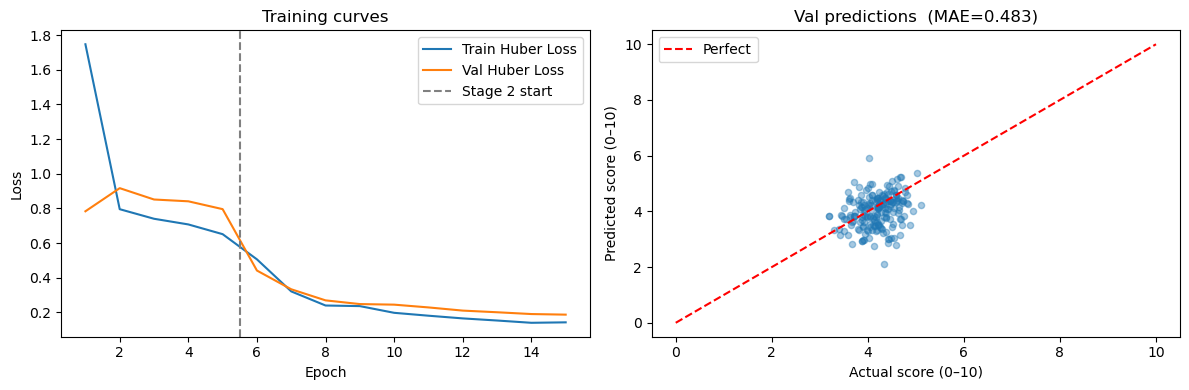

Plot saved → /mnt/c/Users/cloud/iCloudDrive/NUS/PropertyLens/05_photo_layer/artifacts/training_curves_20260412.png


In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Training curves
all_history = [
    {**h, 'stage': 1} for h in stage1_history
] + [
    {**h, 'stage': 2, 'epoch': h['epoch'] + STAGE1_EPOCHS} for h in stage2_history
]
hist_df = pd.DataFrame(all_history)

axes[0].plot(hist_df['epoch'], hist_df['train_loss'], label='Train Huber Loss')
axes[0].plot(hist_df['epoch'], hist_df['val_loss'],   label='Val Huber Loss')
axes[0].axvline(x=STAGE1_EPOCHS + 0.5, color='grey', linestyle='--', label='Stage 2 start')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Training curves'); axes[0].legend()

# Pred vs actual scatter
axes[1].scatter(targets_arr, preds_arr, alpha=0.4, s=20)
axes[1].plot([0, 10], [0, 10], 'r--', label='Perfect')
axes[1].set_xlabel('Actual score (0–10)')
axes[1].set_ylabel('Predicted score (0–10)')
axes[1].set_title(f'Val predictions  (MAE={final_mae:.3f})')
axes[1].legend()

plt.tight_layout()
plot_path = ARTIFACT_DIR / f'training_curves_{TODAY}.png'
plt.savefig(plot_path, dpi=120)
plt.show()
print(f'Plot saved → {plot_path}')